# ADNI Patient Data Diversity Visualizations

The notebook focuses on the diversity and coverage of our ADNI dataset, showing:
1. **Data Modality Distribution** — MRI Only vs Tabular Only vs MRI + Tabular
2. **Longitudinal Data Availability** — Tabular & MRI data available over 36 months
3. **Correlation Matrix** — Key features by diagnosis class
4. **Brain Atrophy Over 36 Months** — Hippocampal, entorhinal & ventricle volume trends
5. **MRI Density per Patient** — Distribution of DICOM file counts

**Diagnosis Classes:** CN (Cognitively Normal, 1), MCI (Mild Cognitive Impairment, 2), AD (Alzheimer's Disease, 3)

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')

In [2]:
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT/'data'
ALPHA_DIR = DATA_DIR/'01_raw'/'ADNI'/'ADNIAlpha'
BETA_DIR = DATA_DIR/'01_raw'/'ADNI'/'ADNIBeta'
FINAL_CSV = DATA_DIR/'02_intermediate'/'adni_final_for_modeling.csv'
LINKED_CSV = DATA_DIR/'03_primary'/'adni_multimodal_linked.csv'
SAVE_DIR = Path(os.getcwd())

In [3]:
plt.rcParams.update({
    'figure.facecolor': '#ffffff',       
    'axes.facecolor':   '#ffffff',     
    'axes.edgecolor':   '#000000',      
    'axes.labelcolor':  '#000000',     
    'text.color':       '#000000',       
    'xtick.color':      '#000000',    
    'ytick.color':      '#000000',    
    'grid.color':       '#e0e0e0',       
    'legend.facecolor': '#ffffff',      
    'legend.edgecolor': '#000000',  
    'font.family':      'serif',
    'font.serif':       ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':         12,
    'axes.titlesize':    16,
    'axes.labelsize':    13,
    'figure.dpi':        120,
    'savefig.dpi':       300,    
    'savefig.bbox':      'tight',
    'savefig.facecolor': '#ffffff',
})

DX_COLORS = {
    1.0: '#1f4e79', # CN
    2.0: '#d35400', # MCI
    3.0: '#a93226' # AD
}
DX_LABELS = {1.0: 'CN (Normal)', 2.0: 'MCI', 3.0: 'AD (Alzheimer\'s)'}
DX_ORDER  = [1.0, 2.0, 3.0]

print(f'Project root: {PROJECT_ROOT}')
print(f'Alpha dir: {ALPHA_DIR} (exists={ALPHA_DIR.exists()})')
print(f'Beta dir: {BETA_DIR} (exists={BETA_DIR.exists()})')

Project root: /Users/nchavez/Projects/school/Classes/COMP549MDSProject/adni-prediction-project
Alpha dir: /Users/nchavez/Projects/school/Classes/COMP549MDSProject/adni-prediction-project/data/01_raw/ADNI/ADNIAlpha (exists=True)
Beta dir: /Users/nchavez/Projects/school/Classes/COMP549MDSProject/adni-prediction-project/data/01_raw/ADNI/ADNIBeta (exists=True)


In [4]:
df_final  = pd.read_csv(FINAL_CSV)
df_linked = pd.read_csv(LINKED_CSV)

print(f'adni_final_for_modeling: {df_final.shape[0]:,} rows, {df_final["PTID"].nunique():,} patients')
print(f'adni_multimodal_linked: {df_linked.shape[0]:,} rows, {df_linked["PTID"].nunique():,} patients')
print(f'Diagnosis distribution: {dict(df_final["DIAGNOSIS"].value_counts().sort_index())}')
print(f'Month range: {df_final["Month"].min()} – {df_final["Month"].max()}')

adni_final_for_modeling: 11,631 rows, 3,762 patients
adni_multimodal_linked: 11,631 rows, 3,762 patients
Diagnosis distribution: {1.0: np.int64(4413), 2.0: np.int64(4984), 3.0: np.int64(2234)}
Month range: 0 – 36


In [5]:
def count_dcm_per_patient(base_dir):
    """Count .dcm files per patient directory"""
    counts = {}
    if not base_dir.exists():
        return counts
    for patient_dir in sorted(base_dir.iterdir()):
        if patient_dir.is_dir() and not patient_dir.name.startswith('.'):
            n = len(list(patient_dir.rglob('*.dcm')))
            counts[patient_dir.name] = n
    return counts

In [6]:
alpha_counts = count_dcm_per_patient(ALPHA_DIR)
print(f'{len(alpha_counts)} patients, {sum(alpha_counts.values()):,} total DICOMs')

beta_counts = count_dcm_per_patient(BETA_DIR)
print(f'{len(beta_counts)} patients, {sum(beta_counts.values()):,} total DICOMs')

333 patients, 83,497 total DICOMs
333 patients, 84,573 total DICOMs


In [7]:
# Merge counts
mri_counts = defaultdict(int)
for ptid, n in alpha_counts.items():
    mri_counts[ptid] += n
for ptid, n in beta_counts.items():
    mri_counts[ptid] += n

In [8]:
mri_ptids = set(mri_counts.keys())
tab_ptids = set(df_final['PTID'].unique())

both_ptids = mri_ptids & tab_ptids
tab_only_ptids = tab_ptids - mri_ptids
mri_only_ptids = mri_ptids - tab_ptids

In [9]:
print(f'Patient Overlap Summary')
print(f'MRI + Tabular: {len(both_ptids)}')
print(f'Tabular Only: {len(tab_only_ptids)}')
print(f'MRI Only: {len(mri_only_ptids)}')

Patient Overlap Summary
MRI + Tabular: 581
Tabular Only: 3181
MRI Only: 0


In [10]:
# Assign each patient a diagnosis
# Use the baseline diagnosis and if missing use mode
baseline = df_final[df_final['Month'] == 0][['PTID', 'DIAGNOSIS']].drop_duplicates('PTID')
ptid_to_dx = dict(zip(baseline['PTID'], baseline['DIAGNOSIS']))

# Fill remaining from mode
for ptid in tab_ptids:
    if ptid not in ptid_to_dx:
        mode = df_final[df_final['PTID'] == ptid]['DIAGNOSIS'].mode()
        if len(mode) > 0:
            ptid_to_dx[ptid] = mode.iloc[0]

# For MRI only patients
for ptid in mri_only_ptids:
    if ptid not in ptid_to_dx:
        ptid_to_dx[ptid] = np.nan  # will be labeled 'Unknown'

print(f'Patients with assigned diagnosis: {len(ptid_to_dx)}')

Patients with assigned diagnosis: 3762


## 1. Data Modality Distribution
Grouped bar chart showing patient counts by data modality and diagnosis class.  
The MRI + Tabular bar is stacked to show the **average number of MRI DICOM images** per patient.

In [11]:
# Data Modality Distribution

# Build per-class counts
modality_data = []
for dx in DX_ORDER:
    dx_patients = {p for p, d in ptid_to_dx.items() if d == dx}
    n_both = len(dx_patients & both_ptids)
    n_tab_only = len(dx_patients & tab_only_ptids)
    n_mri_only = len(dx_patients & mri_only_ptids)
    
    # Avg MRI images for patients with MRI
    mri_patients_in_class = dx_patients & both_ptids
    avg_mri = np.mean([mri_counts[p] for p in mri_patients_in_class]) if mri_patients_in_class else 0
    
    modality_data.append({
        'Diagnosis': DX_LABELS[dx],
        'MRI + Tabular': n_both,
        'Tabular Only': n_tab_only,
        'MRI Only': n_mri_only,
        'Avg MRI Images': avg_mri,
    })
df_mod = pd.DataFrame(modality_data)
print(df_mod.to_string(index=False))

       Diagnosis  MRI + Tabular  Tabular Only  MRI Only  Avg MRI Images
     CN (Normal)            342          1252         0      288.432749
             MCI            230          1370         0      291.139130
AD (Alzheimer's)              9           559         0      273.777778


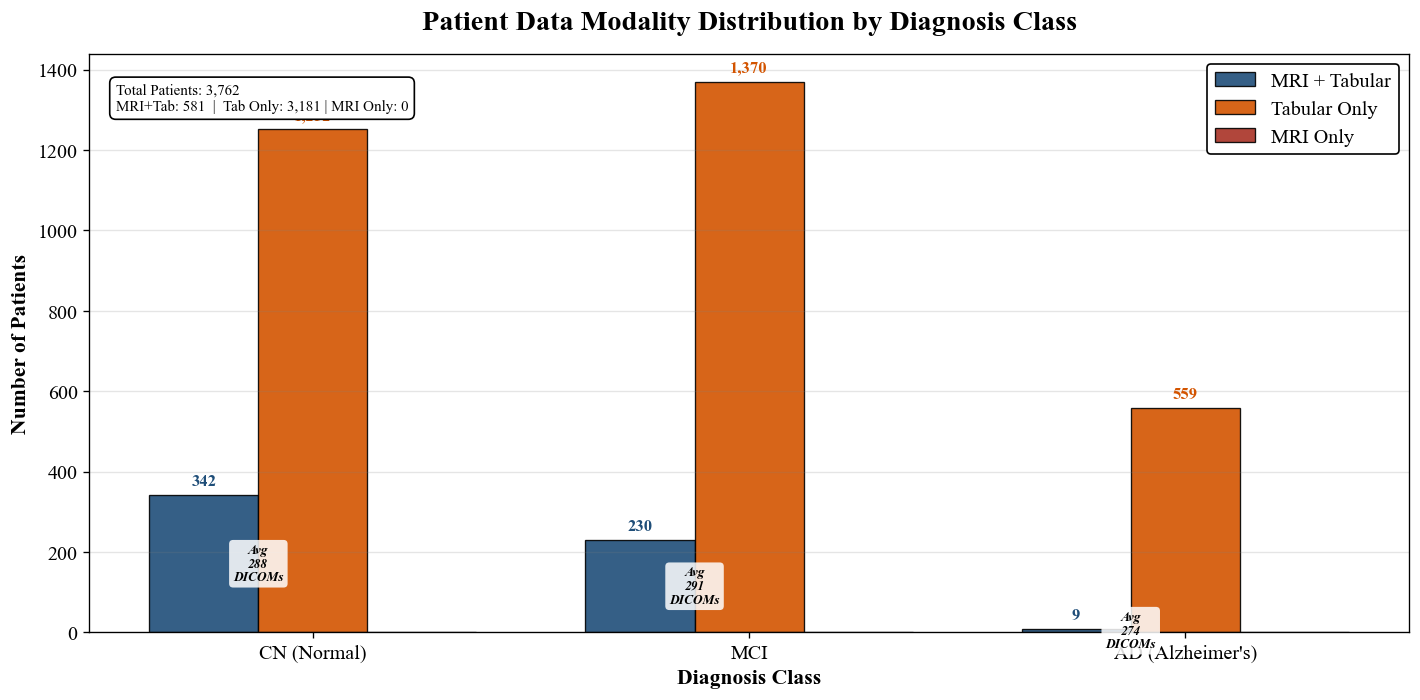

In [12]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(DX_ORDER))
bar_w = 0.25

colors_mod = ['#1f4e79', '#d35400', '#a93226'] 
modalities = ['MRI + Tabular', 'Tabular Only', 'MRI Only']
hatches    = ['', '', '']

for i, mod in enumerate(modalities):
    vals = df_mod[mod].values
    bars = ax.bar(x + i * bar_w, vals, bar_w, label=mod,
                  color=colors_mod[i], alpha=0.9, edgecolor='black', linewidth=0.8)
    
    # Annotate counts
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                    f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color=colors_mod[i])

# Add avg MRI count annotations on the MRI+Tabular bars
for j, (_, row) in enumerate(df_mod.iterrows()):
    if row['MRI + Tabular'] > 0 and row['Avg MRI Images'] > 0:
        bar_x = x[j]
        bar_h = row['MRI + Tabular']
        ax.text(bar_x + bar_w/2, bar_h * 0.5,
                f'Avg\n{row["Avg MRI Images"]:.0f}\nDICOMs',
                ha='center', va='center', fontsize=8, color='black',
                fontweight='bold', fontstyle='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))

ax.set_xlabel('Diagnosis Class', fontweight='bold')
ax.set_ylabel('Number of Patients', fontweight='bold')
ax.set_title('Patient Data Modality Distribution by Diagnosis Class',
             fontweight='bold', fontsize=17, pad=15)
ax.set_xticks(x + bar_w)
ax.set_xticklabels([DX_LABELS[d] for d in DX_ORDER])
ax.legend(loc='upper right', framealpha=1.0, edgecolor='black')
ax.grid(axis='y', alpha=0.2, color='gray')

# Summary text box
summary = (f'Total Patients: {len(tab_ptids | mri_ptids):,}\n'
           f'MRI+Tab: {len(both_ptids):,}  |  Tab Only: {len(tab_only_ptids):,} | MRI Only: {len(mri_only_ptids):,}')

ax.text(0.02, 0.95, summary, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', color='black',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1.0, edgecolor='black'))

plt.tight_layout()
fig.savefig(SAVE_DIR / 'patient_diversity.png')
plt.show()

## 2. Longitudinal Data Availability Over 36 Months
Stacked bar chart showing how much tabular and MRI data is available at each month.

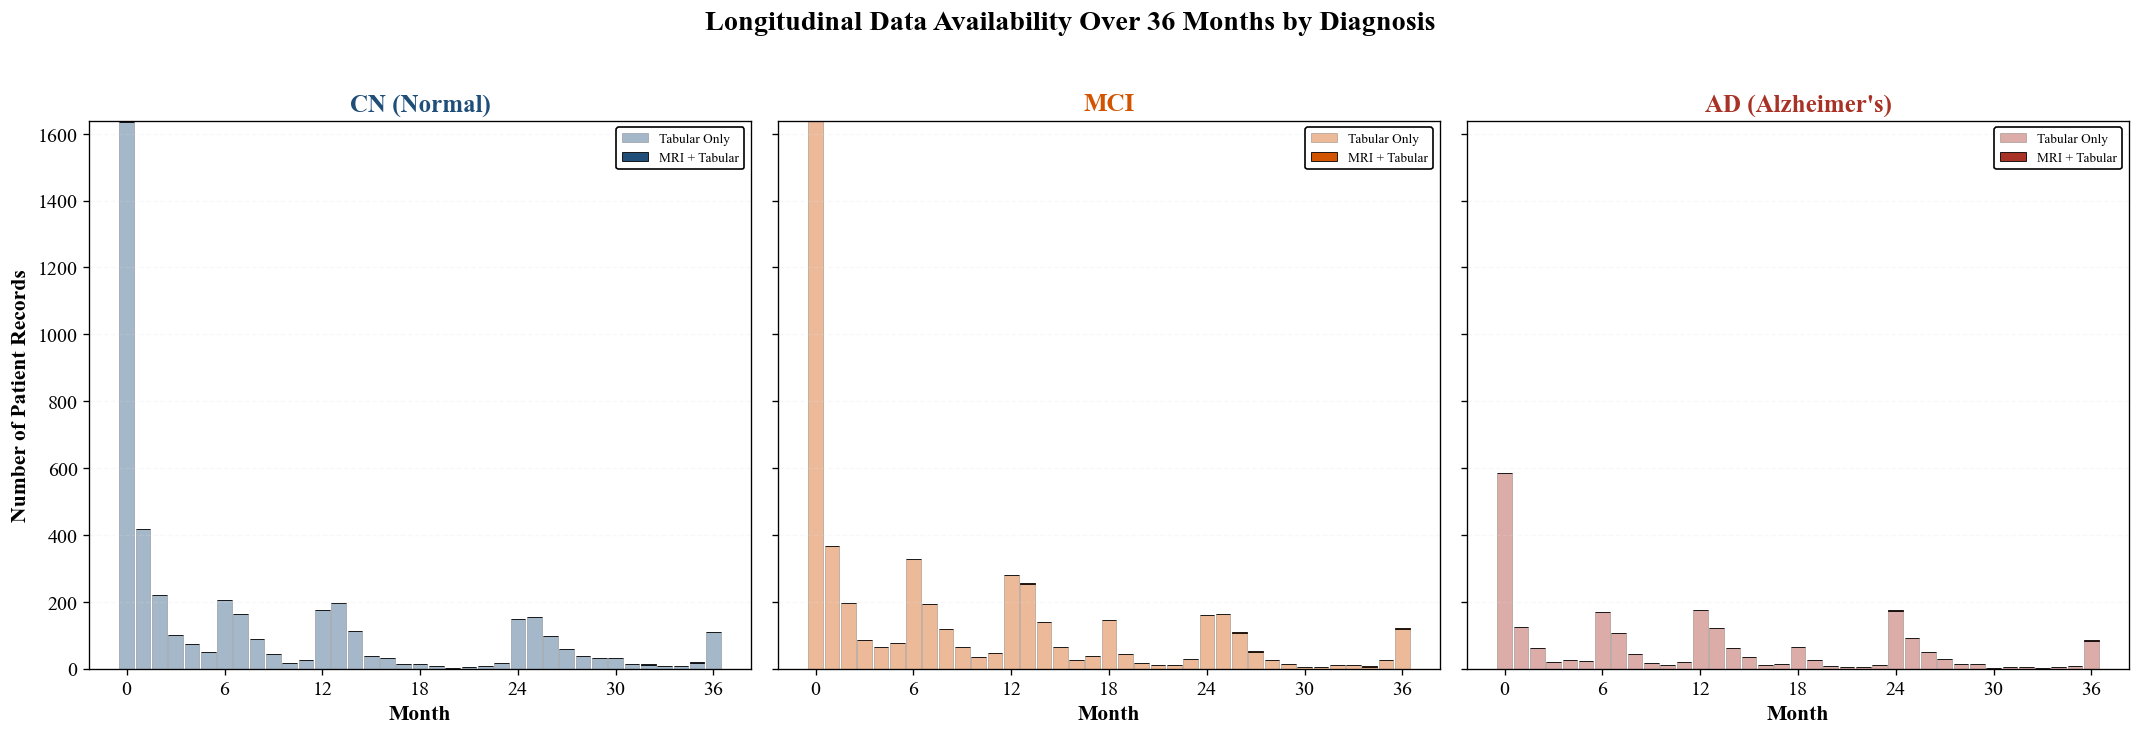

In [13]:
# Longitudinal Data Availability

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

months = list(range(0, 37))

for idx, dx in enumerate(DX_ORDER):
    ax = axes[idx]
    # Filter data for this diagnosis
    dx_df = df_linked[df_linked['DIAGNOSIS'] == dx]
    
    tab_counts = []
    mri_counts_monthly = []
    
    # Aggregate counts per month
    for m in months:
        month_df = dx_df[dx_df['Month'] == m]
        tab_counts.append(len(month_df))
        mri_counts_monthly.append(month_df['Has_Image'].sum() if 'Has_Image' in month_df.columns else 0)
    
    tab_arr = np.array(tab_counts)
    mri_arr = np.array(mri_counts_monthly)
    tab_only_arr = tab_arr - mri_arr
    
    ax.bar(months, tab_only_arr, color=DX_COLORS[dx], alpha=0.4, 
           label='Tabular Only', width=0.9, edgecolor='black', linewidth=0.3)
    
    ax.bar(months, mri_arr, bottom=tab_only_arr, color=DX_COLORS[dx], alpha=1.0,
           label='MRI + Tabular', edgecolor='black', linewidth=0.5, width=0.9)
    
    ax.set_title(DX_LABELS[dx], fontweight='bold', fontsize=15, color=DX_COLORS[dx])
    ax.set_xlabel('Month', fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Number of Patient Records', fontweight='bold')
        
    ax.set_xticks([0, 6, 12, 18, 24, 30, 36])
    
    ax.legend(loc='upper right', fontsize=8, framealpha=1.0, edgecolor='black')
    ax.grid(axis='y', alpha=0.2, linestyle='--')

fig.suptitle('Longitudinal Data Availability Over 36 Months by Diagnosis',
             fontweight='bold', fontsize=17, y=1.02, color='black')
plt.tight_layout()
fig.savefig(SAVE_DIR / 'longitudinal_availability.png', bbox_inches='tight')
plt.show()

## 3. Refined Correlation Matrix
Heatmap of key biomarker, cognitive, and brain volume features — one panel per diagnosis class.

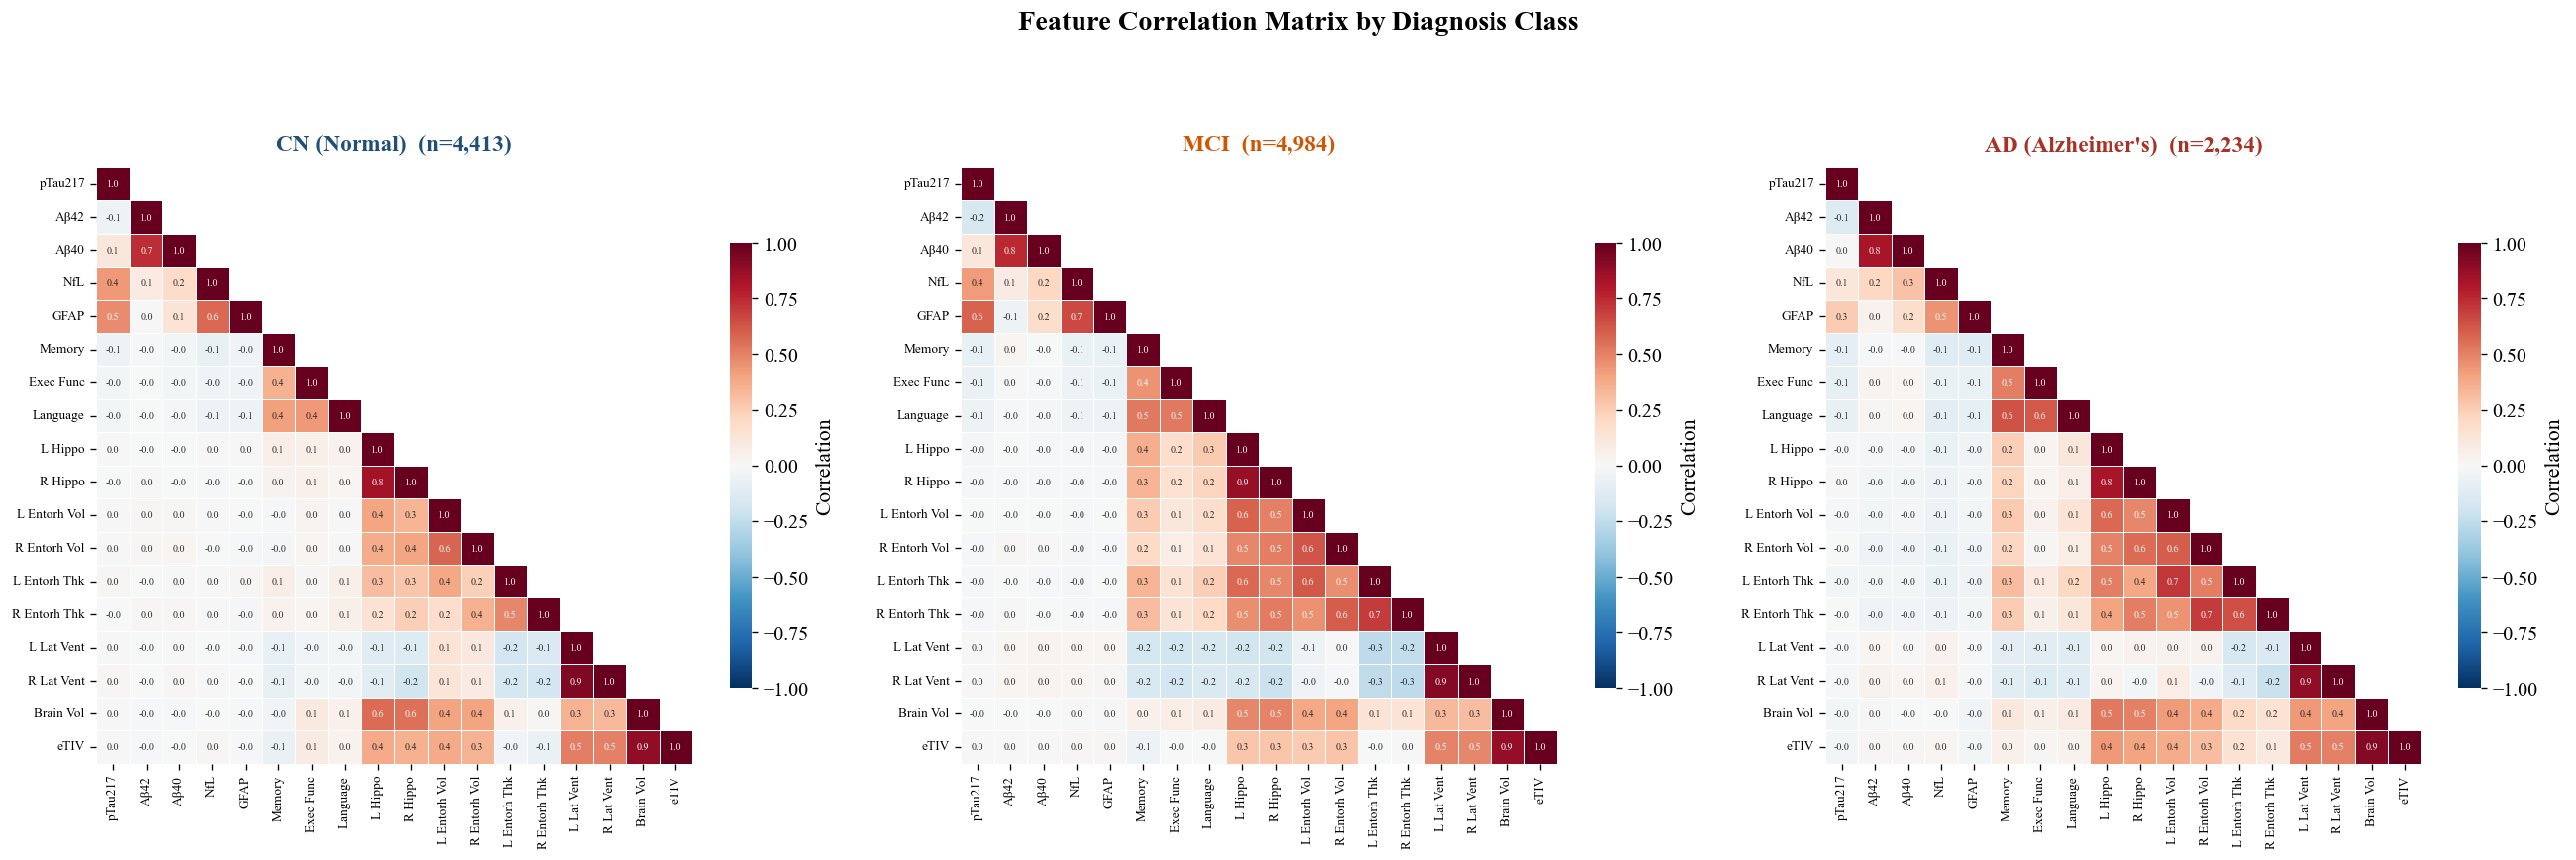

In [14]:
# Correlation Matrix

# Select key features for the correlation matrix
corr_features = [
    'pT217_F', 'AB42_F', 'AB40_F', 'NfL_Q', 'GFAP_Q',
    'PHC_MEM', 'PHC_EXF', 'PHC_LAN',
    'Left.Hippocampus_combat', 'Right.Hippocampus_combat',
    'lh_entorhinal_volume_combat', 'rh_entorhinal_volume_combat',
    'lh_entorhinal_thickness_combat', 'rh_entorhinal_thickness_combat',
    'Left.Lateral.Ventricle_combat', 'Right.Lateral.Ventricle_combat',
    'BrainSegVol_combat', 'EstimatedTotalIntraCranialVol_combat'
]

# Short labels for readability
short_labels = [
    'pTau217', 'Aβ42', 'Aβ40', 'NfL', 'GFAP',
    'Memory', 'Exec Func', 'Language',
    'L Hippo', 'R Hippo',
    'L Entorh Vol', 'R Entorh Vol',
    'L Entorh Thk', 'R Entorh Thk',
    'L Lat Vent', 'R Lat Vent',
    'Brain Vol', 'eTIV'
]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, dx in enumerate(DX_ORDER):
    ax = axes[idx]
    # Filter for specific diagnosis and features
    dx_subset = df_final[df_final['DIAGNOSIS'] == dx][corr_features].dropna()
    
    # Handle insufficient data cases
    if len(dx_subset) < 5:
        ax.text(0.5, 0.5, f'Insufficient data\n(n={len(dx_subset)})',
                ha='center', va='center', transform=ax.transAxes, color='black', fontsize=12)
        ax.set_title(DX_LABELS[dx], fontweight='bold', color=DX_COLORS[dx])
        ax.axis('off') # Hide axis if no data
        continue
    
    corr = dx_subset.corr()
    
    # Apply short labels
    corr.index = short_labels
    corr.columns = short_labels
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5,
                linecolor='white',  # Clean white grid lines
                cbar_kws={'shrink': 0.6, 'label': 'Correlation'},
                annot=True, fmt='.1f', annot_kws={'size': 6})
    
    ax.set_title(f'{DX_LABELS[dx]}  (n={len(dx_subset):,})',
                 fontweight='bold', fontsize=14, color=DX_COLORS[dx], pad=10)
    ax.tick_params(labelsize=8)

fig.suptitle('Feature Correlation Matrix by Diagnosis Class',
             fontweight='bold', fontsize=17, y=1.02, color='black')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'correlation_matrix.png', bbox_inches='tight')
plt.show()

## 4. Brain Atrophy Over 36 Months
Line plots showing mean brain volume changes over time for each diagnosis class.  
Tracks: Hippocampus (L+R), Entorhinal cortex volume, and Lateral Ventricle volume.

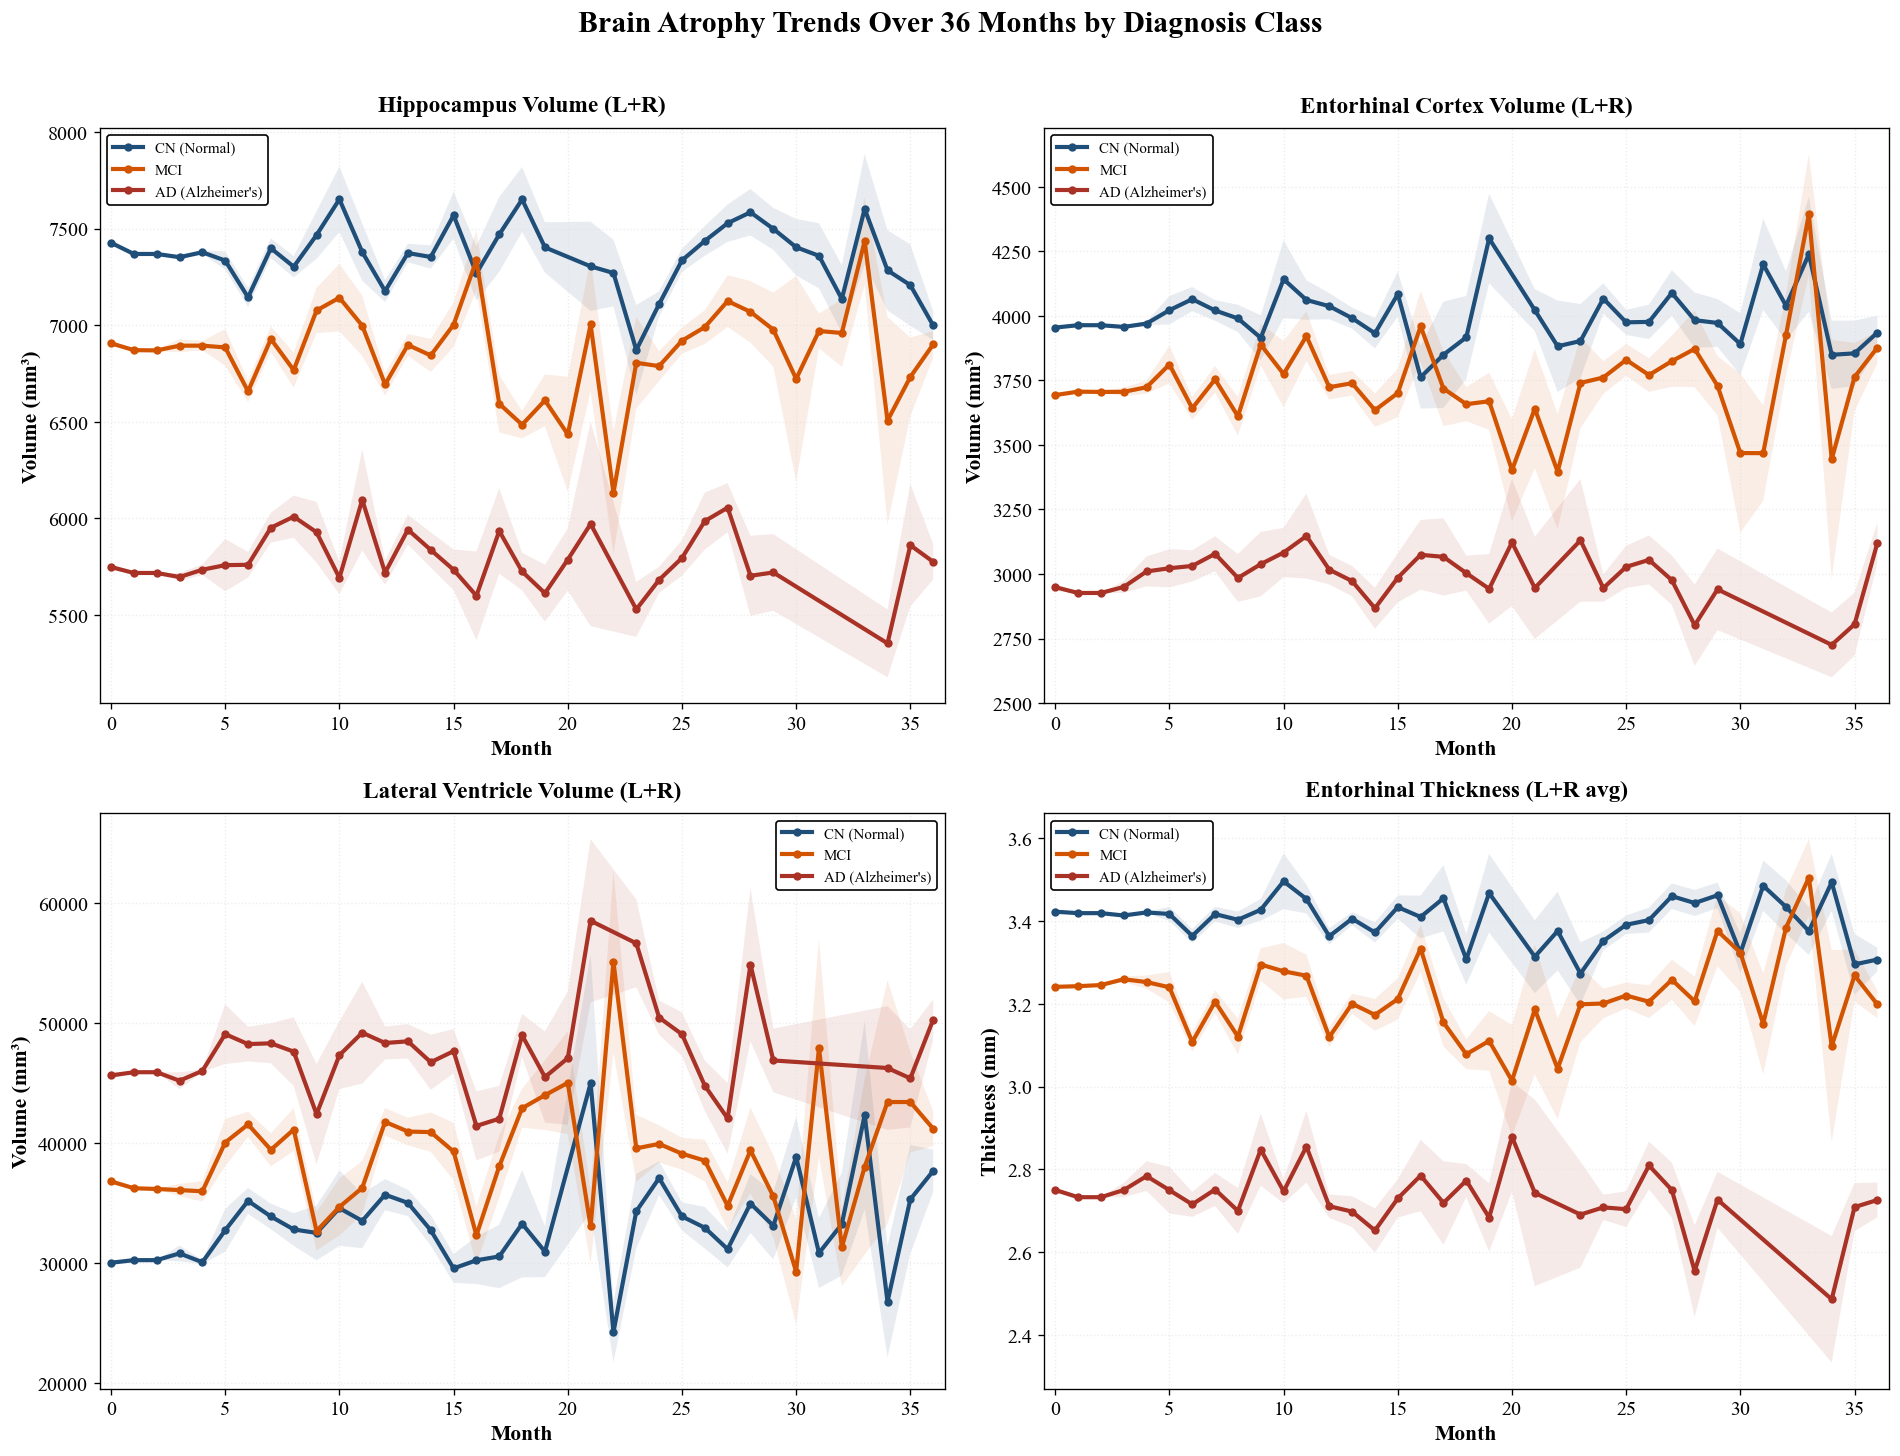

In [15]:
# Brain Atrophy Over 36 Months

atrophy_metrics = {
    'Hippocampus Volume (L+R)': ('Left.Hippocampus_combat', 'Right.Hippocampus_combat'),
    'Entorhinal Cortex Volume (L+R)': ('lh_entorhinal_volume_combat', 'rh_entorhinal_volume_combat'),
    'Lateral Ventricle Volume (L+R)': ('Left.Lateral.Ventricle_combat', 'Right.Lateral.Ventricle_combat'),
    'Entorhinal Thickness (L+R avg)': ('lh_entorhinal_thickness_combat', 'rh_entorhinal_thickness_combat'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Iterate through the 4 metrics
for i, (title, (col_l, col_r)) in enumerate(atrophy_metrics.items()):
    ax = axes[i]
    
    # Create temporary metric column
    # For Thickness, we usually average L+R. For Volume, we sum L+R
    if 'Thickness' in title:
        df_final['_metric'] = (df_final[col_l] + df_final[col_r]) / 2.0
    else:
        df_final['_metric'] = df_final[col_l] + df_final[col_r]
    
    # Plot trend for each diagnosis group
    for dx in DX_ORDER:
        # Filter for specific diagnosis and valid metric data
        dx_data = df_final[df_final['DIAGNOSIS'] == dx].dropna(subset=['_metric'])
        
        if len(dx_data) < 5:
            continue
            
        # Group by month to get mean and standard error
        grouped = dx_data.groupby('Month')['_metric'].agg(['mean', 'sem', 'count'])
        
        # Only show points where n >= 5 to avoid noise
        grouped = grouped[grouped['count'] >= 5]
        
        if grouped.empty:
            continue

        # Plot Line
        ax.plot(grouped.index, grouped['mean'], 
                color=DX_COLORS[dx], label=DX_LABELS[dx], 
                linewidth=2.5, marker='o', markersize=4, alpha=1.0)
        
        # Plot error band
        ax.fill_between(grouped.index,
                        grouped['mean'] - grouped['sem'],
                        grouped['mean'] + grouped['sem'],
                        color=DX_COLORS[dx], alpha=0.1, edgecolor=None)
    
    # Formatting
    ax.set_title(title, fontweight='bold', fontsize=14, pad=10, color='black')
    ax.set_xlabel('Month', fontweight='bold')
    
    # Dynamic label based on metric type
    if 'Thickness' in title:
        ax.set_ylabel('Thickness (mm)', fontweight='bold')
    else:
        ax.set_ylabel('Volume (mm³)', fontweight='bold')
        
    ax.legend(loc='best', fontsize=9, framealpha=1.0, edgecolor='black')
    
    ax.grid(True, linestyle=':', alpha=0.6, color='#e0e0e0')
    ax.set_xlim(-0.5, 36.5)

# Clean up temp column
if '_metric' in df_final.columns:
    df_final.drop(columns=['_metric'], inplace=True)

fig.suptitle('Brain Atrophy Trends Over 36 Months by Diagnosis Class',
             fontweight='bold', fontsize=18, y=1.01, color='black')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'brain_atrophy.png', bbox_inches='tight')
plt.show()

## 5. MRI Density per Patient
Distribution of DICOM file counts per patient, colored by diagnosis class.

MRI patients with diagnosis: 581
DICOM count stats:
           count   mean    std    min    25%    50%    75%     max
DIAGNOSIS                                                         
1.0        342.0  288.4  138.1    2.0  208.0  208.0  384.0  1056.0
2.0        230.0  291.1  136.3    2.0  208.0  208.0  384.0   948.0
3.0          9.0  273.8  110.2  176.0  208.0  208.0  416.0   422.0


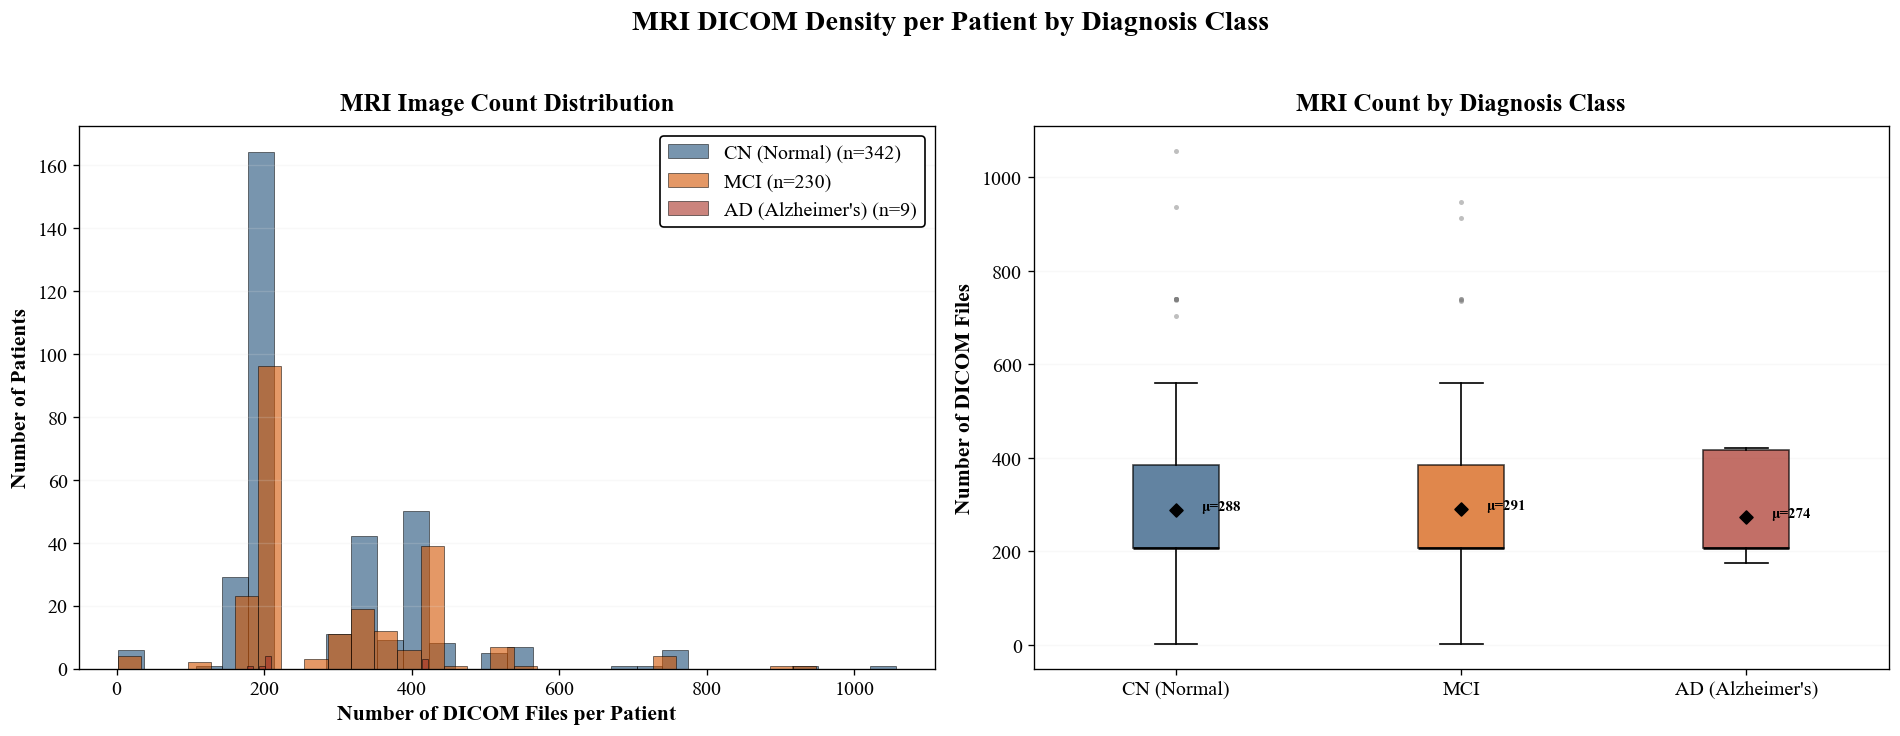

In [16]:
# MRI Density per Patient

# Build DataFrame of MRI patients with their diagnosis and DICOM count
mri_df_rows = []
for ptid in mri_ptids:
    dx = ptid_to_dx.get(ptid, np.nan)
    count = mri_counts[ptid]
    mri_df_rows.append({'PTID': ptid, 'DIAGNOSIS': dx, 'DICOM_Count': count})

mri_df = pd.DataFrame(mri_df_rows)
mri_df = mri_df.dropna(subset=['DIAGNOSIS'])

print(f'MRI patients with diagnosis: {len(mri_df)}')
print(f'DICOM count stats:')
print(mri_df.groupby('DIAGNOSIS')['DICOM_Count'].describe().round(1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for dx in DX_ORDER:
    subset = mri_df[mri_df['DIAGNOSIS'] == dx]['DICOM_Count']
    if len(subset) > 0:
        ax1.hist(subset, bins=30, alpha=0.6, label=f'{DX_LABELS[dx]} (n={len(subset)})',
                 color=DX_COLORS[dx], edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Number of DICOM Files per Patient', fontweight='bold')
ax1.set_ylabel('Number of Patients', fontweight='bold')
ax1.set_title('MRI Image Count Distribution', fontweight='bold', fontsize=15, pad=10)
ax1.legend(loc='upper right', framealpha=1.0, edgecolor='black')
ax1.grid(axis='y', alpha=0.2, color='#e0e0e0')

plot_data = []
plot_labels = []
plot_colors = []

for dx in DX_ORDER:
    subset = mri_df[mri_df['DIAGNOSIS'] == dx]['DICOM_Count']
    if len(subset) > 0:
        plot_data.append(subset.values)
        plot_labels.append(DX_LABELS[dx])
        plot_colors.append(DX_COLORS[dx])

bp = ax2.boxplot(plot_data, labels=plot_labels, patch_artist=True,
                 medianprops=dict(color='black', linewidth=1.5),
                 whiskerprops=dict(color='black', linewidth=1),  
                 capprops=dict(color='black', linewidth=1),    
                 flierprops=dict(marker='o', markersize=3, alpha=0.5, 
                               markerfacecolor='gray', markeredgecolor='none'))

for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

ax2.set_ylabel('Number of DICOM Files', fontweight='bold')
ax2.set_title('MRI Count by Diagnosis Class', fontweight='bold', fontsize=15, pad=10)
ax2.grid(axis='y', alpha=0.2, color='#e0e0e0')

# Add mean annotations
for i, data in enumerate(plot_data):
    mean_val = np.mean(data)
    ax2.scatter(i+1, mean_val, color='black', marker='D', s=30, zorder=5)
    ax2.annotate(f'μ={mean_val:.0f}', (i+1, mean_val), textcoords='offset points',
                 xytext=(15, 0), fontsize=9, color='black', fontweight='bold')

fig.suptitle('MRI DICOM Density per Patient by Diagnosis Class',
             fontweight='bold', fontsize=17, y=1.02, color='black')

plt.tight_layout()
fig.savefig(SAVE_DIR / 'mri_density.png', bbox_inches='tight')
plt.show()

## Summary Statistics

In [17]:
# Final Summary
print('ADNI PATIENT DATA DIVERSITY — SUMMARY')
print(f'Total unique tabular patients: {len(tab_ptids):>6,}')
print(f'Total unique MRI patients: {len(mri_ptids):>6,}')
print(f'Patients with MRI + Tabular: {len(both_ptids):>6,}')
print(f'Patients with Tabular Only: {len(tab_only_ptids):>6,}')
print(f'Patients with MRI Only: {len(mri_only_ptids):>6,}')
print(f'Total DICOM files: {sum(mri_counts.values()):>6,}')
print(f'Avg DICOMs per MRI patient: {np.mean(list(mri_counts.values())):>6.0f}')
for dx in DX_ORDER:
    dx_patients = {p for p, d in ptid_to_dx.items() if d == dx}
    n_total = len(dx_patients)
    n_mri = len(dx_patients & mri_ptids)
    print(f'{DX_LABELS[dx]:<30s}: {n_total:>5,} patients ({n_mri:>4,} with MRI)')
print()
for f in ['patient_diversity.png', 'longitudinal_availability.png',
          'correlation_matrix.png', 'brain_atrophy.png', 'mri_density.png']:
    path = SAVE_DIR / f
    exists = 'Good' if path.exists() else '✗'
    print(f'{exists} {f}')

ADNI PATIENT DATA DIVERSITY — SUMMARY
Total unique tabular patients:  3,762
Total unique MRI patients:    581
Patients with MRI + Tabular:    581
Patients with Tabular Only:  3,181
Patients with MRI Only:      0
Total DICOM files: 168,070
Avg DICOMs per MRI patient:    289
CN (Normal)                   : 1,594 patients ( 342 with MRI)
MCI                           : 1,600 patients ( 230 with MRI)
AD (Alzheimer's)              :   568 patients (   9 with MRI)

Good patient_diversity.png
Good longitudinal_availability.png
Good correlation_matrix.png
Good brain_atrophy.png
Good mri_density.png
